In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("revenue_lift_9pct_30000.csv")
data

,Date,Product ID,Product Name,Category,Pricing_Type,Price,Cost Price,Units Sold,Visitors,Conversion Rate %,Revenue,Profit,Profit Margin %,Stock Level,Inventory Turnover,Competitor Price,Restock Date
0,2024-01-15,P00001,Product_1,Toys,Baseline,131.74,100.19,353,19768,1.7857,46504.22,11137.15,23.9487,3391,0.1041,135.02,2025-02-09
1,2024-07-02,P00002,Product_2,Home,Baseline,667.26,496.56,410,5330,7.6923,273576.60,69987.00,25.5822,4677,0.0877,651.28,2025-12-23
2,2024-10-15,P00003,Product_3,Sports,Baseline,349.25,290.25,101,9595,1.0526,35274.25,5959.00,16.8933,282,0.3582,362.79,2023-07-07
3,2024-07-07,P00004,Product_4,Toys,Baseline,232.91,191.18,304,24320,1.2500,70804.64,12685.92,17.9168,3171,0.0959,222.23,2024-08-13
4,2024-04-16,P00005,Product_5,Fashion,Baseline,190.07,158.34,64,768,8.3333,12164.48,2030.72,16.6938,1286,0.0498,180.77,2024-09-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2023-02-25,P14996,Product_14996,Sports,Dynamic,283.52,212.30,317,16726,1.8953,89875.84,22576.74,25.1199,1920,0.1651,274.57,2024-11-08
29996,2023-03-08,P14997,Product_14997,Fashion,Dynamic,76.11,52.82,70,5720,1.2238,5327.70,1630.30,30.6004,4406,0.0159,74.99,2023-02-25
29997,2023-09-29,P14998,Product_14998,Beauty,Dynamic,385.62,307.09,296,20508,1.4433,114143.52,23244.88,20.3646,2013,0.1470,368.92,2024-07-25
29998,2023-08-13,P14999,Product_14999,Electronics,Dynamic,674.08,482.09,504,31836,1.5831,339736.32,96762.96,28.4818,699,0.7210,652.13,2024-11-11


In [5]:
data.shape

(30000, 17)

In [7]:
data.isnull().sum()

Date                  0
Product ID            0
Product Name          0
Category              0
Pricing_Type          0
Price                 0
Cost Price            0
Units Sold            0
Visitors              0
Conversion Rate %     0
Revenue               0
Profit                0
Profit Margin %       0
Stock Level           0
Inventory Turnover    0
Competitor Price      0
Restock Date          0
dtype: int64

In [9]:
data.duplicated().sum()

0

In [11]:
data.dtypes

Date                   object
Product ID             object
Product Name           object
Category               object
Pricing_Type           object
Price                 float64
Cost Price            float64
Units Sold              int64
Visitors                int64
Conversion Rate %     float64
Revenue               float64
Profit                float64
Profit Margin %       float64
Stock Level             int64
Inventory Turnover    float64
Competitor Price      float64
Restock Date           object
dtype: object

In [13]:
data.describe()

,Price,Cost Price,Units Sold,Visitors,Conversion Rate %,Revenue,Profit,Profit Margin %,Stock Level,Inventory Turnover,Competitor Price
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,339.777992,259.430199,258.165333,15924.137300,2.858014,87601.972782,20767.370308,23.366200,2499.346867,0.516033,339.841385
std,182.279473,138.088564,143.997572,13145.496186,3.244987,72896.056680,18686.214002,4.824087,1442.911490,7.156551,182.697209
min,23.310000,20.000000,10.000000,59.000000,0.809000,343.700000,61.400000,13.043200,0.000000,0.002000,22.560000
25%,183.847500,141.075000,133.000000,5043.750000,1.104575,28153.042500,6279.615000,19.653375,1241.000000,0.053400,183.377500
50%,337.485000,258.655000,257.000000,12419.000000,1.628200,66930.040000,15144.480000,23.626450,2497.000000,0.103500,337.335000
75%,494.805000,377.577500,384.000000,23808.000000,3.030300,129578.892500,29991.552500,27.170025,3747.000000,0.206125,494.505000
max,737.520000,499.950000,527.000000,60856.000000,21.360500,370754.700000,116547.750000,33.178100,4999.000000,526.000000,768.850000


In [15]:
# Negative or invalid values
print("\nInvalid values check:")
print("Units Sold <= 0:", (data["Units Sold"] <= 0).sum())
print("Price <= 0:", (data["Price"] <= 0).sum())
print("Revenue <= 0:", (data["Revenue"] <= 0).sum())
print("Cost Price <= 0:", (data["Cost Price"] <= 0).sum())
print("Stock Level < 0:", (data["Stock Level"] < 0).sum())


Invalid values check:
Units Sold <= 0: 0
Price <= 0: 0
Revenue <= 0: 0
Cost Price <= 0: 0
Stock Level < 0: 0


In [17]:
#revenue lift
data["Baseline_Revenue"] = (data["Cost Price"] * 1.20) * data["Units Sold"]

revenue_lift = (
    (data["Revenue"].sum() - data["Baseline_Revenue"].sum())
    / data["Baseline_Revenue"].sum()
) * 100

print(f"Revenue Lift: {revenue_lift:.2f}%")


Revenue Lift: 9.23%


In [19]:
#Profit Margin
data["Profit"] = data["Revenue"] - (data["Cost Price"] * data["Units Sold"])

profit_margin = (data["Profit"].sum() / data["Revenue"].sum()) * 100

print(f"Profit Margin: {profit_margin:.2f}%")


Profit Margin: 23.71%


In [21]:
#Conversion Rate
conversion_rate = (data["Units Sold"].sum() / data["Visitors"].sum()) * 100

print(f"Conversion Rate: {conversion_rate:.2f}%")


Conversion Rate: 1.62%


In [23]:
#Inventory Turnover
inventory_turnover = data["Units Sold"].sum() / data["Stock Level"].mean()

print(f"Inventory Turnover: {inventory_turnover:.2f}")


Inventory Turnover: 3098.79


In [25]:
data["Date"] = pd.to_datetime(data["Date"])

data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year
data["DayOfWeek"] = data["Date"].dt.weekday
data["Weekend"] = data["DayOfWeek"].isin([5, 6]).astype(int)

# Season (India)
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Rainy"
    else:
        return "Autumn"

data["Season"] = data["Month"].apply(get_season)

# Holiday flag (simple proxy)
data["Holiday"] = data["Weekend"]


In [27]:
data["Lag_Sales_1"] = data.groupby("Product ID")["Units Sold"].shift(1)
data["Lag_Sales_7"] = data.groupby("Product ID")["Units Sold"].shift(7)
data["Lag_Sales_30"] = data.groupby("Product ID")["Units Sold"].shift(30)

data["Rolling_7"] = data.groupby("Product ID")["Units Sold"].rolling(7).mean().reset_index(0, drop=True)
data["Rolling_30"] = data.groupby("Product ID")["Units Sold"].rolling(30).mean().reset_index(0, drop=True)

data["Demand_Volatility"] = data.groupby("Product ID")["Units Sold"].rolling(7).std().reset_index(0, drop=True)


In [28]:
# ---------- PRICE CHANGE ----------
data = data.sort_values(["Product ID", "Date"])

data["Lag_Price_1"] = data.groupby("Product ID")["Price"].shift(1)

data["Price_Change_%"] = (
    (data["Price"] - data["Lag_Price_1"]) / data["Lag_Price_1"]
) * 100


In [29]:
data["Elasticity"] = data["Price_Change_%"] / (
    (data["Units Sold"] - data["Lag_Sales_1"]) / data["Lag_Sales_1"]
)

def elasticity_class(x):
    if abs(x) > 1:
        return "High"
    elif abs(x) > 0.5:
        return "Medium"
    else:
        return "Low"

data["Elasticity_Class"] = data["Elasticity"].apply(elasticity_class)


In [33]:
data["Competitor_Diff"] = data["Price"] - data["Competitor Price"]
data["Competitor_Index"] = data["Price"] / data["Competitor Price"]
data["Competitor_Cheaper"] = (data["Competitor Price"] < data["Price"]).astype(int)


In [35]:
data["Inventory_Ratio"] = data["Units Sold"] / data["Stock Level"]
data["Days_To_Stockout"] = data["Stock Level"] / data["Units Sold"]

data["Low_Stock"] = (data["Stock Level"] < data["Stock Level"].quantile(0.25)).astype(int)
data["Over_Stock"] = (data["Stock Level"] > data["Stock Level"].quantile(0.75)).astype(int)


In [37]:
data["Profit_Per_Unit"] = data["Profit"] / data["Units Sold"]
data["Profit_Margin_Feature"] = (data["Profit"] / data["Revenue"]) * 100


In [39]:
data["Discount_%"] = (
    (data["Competitor Price"] - data["Price"]) / data["Competitor Price"]
) * 100


In [41]:
data["Weekend_Price"] = data["Weekend"] * data["Price"]

data["Season_Discount"] = data["Discount_%"] * (
    data["Season"] == "Summer"
).astype(int)

data["Inventory_Price"] = data["Stock Level"] * data["Price"]


In [43]:
data.columns

Index(['Date', 'Product ID', 'Product Name', 'Category', 'Pricing_Type',
       'Price', 'Cost Price', 'Units Sold', 'Visitors', 'Conversion Rate %',
       'Revenue', 'Profit', 'Profit Margin %', 'Stock Level',
       'Inventory Turnover', 'Competitor Price', 'Restock Date',
       'Baseline_Revenue', 'Day', 'Month', 'Year', 'DayOfWeek', 'Weekend',
       'Season', 'Holiday', 'Lag_Sales_1', 'Lag_Sales_7', 'Lag_Sales_30',
       'Rolling_7', 'Rolling_30', 'Demand_Volatility', 'Lag_Price_1',
       'Price_Change_%', 'Elasticity', 'Elasticity_Class', 'Competitor_Diff',
       'Competitor_Index', 'Competitor_Cheaper', 'Inventory_Ratio',
       'Days_To_Stockout', 'Low_Stock', 'Over_Stock', 'Profit_Per_Unit',
       'Profit_Margin_Feature', 'Discount_%', 'Weekend_Price',
       'Season_Discount', 'Inventory_Price'],
      dtype='object')

In [45]:
data.isnull().sum()

Date                         0
Product ID                   0
Product Name                 0
Category                     0
Pricing_Type                 0
Price                        0
Cost Price                   0
Units Sold                   0
Visitors                     0
Conversion Rate %            0
Revenue                      0
Profit                       0
Profit Margin %              0
Stock Level                  0
Inventory Turnover           0
Competitor Price             0
Restock Date                 0
Baseline_Revenue             0
Day                          0
Month                        0
Year                         0
DayOfWeek                    0
Weekend                      0
Season                       0
Holiday                      0
Lag_Sales_1              15000
Lag_Sales_7              30000
Lag_Sales_30             30000
Rolling_7                30000
Rolling_30               30000
Demand_Volatility        30000
Lag_Price_1              15000
Price_Ch

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data["Product_ID_Enc"] = le.fit_transform(data["Product ID"])
data["Category_Enc"] = le.fit_transform(data["Category"])
data["Pricing_Type_Enc"] = le.fit_transform(data["Pricing_Type"])


In [49]:
data.drop_duplicates(inplace=True)
data.fillna(0, inplace=True)


In [51]:
data.replace([float("inf"), -float("inf")], 0, inplace=True)

In [53]:
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns


In [55]:
Q1 = data[numeric_cols].quantile(0.25)
Q3 = data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

data = data[~((data[numeric_cols] < (Q1 - 1.5 * IQR)) |
              (data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [57]:
print("Rows after outlier removal:", data.shape[0])


Rows after outlier removal: 8371


In [59]:
#milestone 3

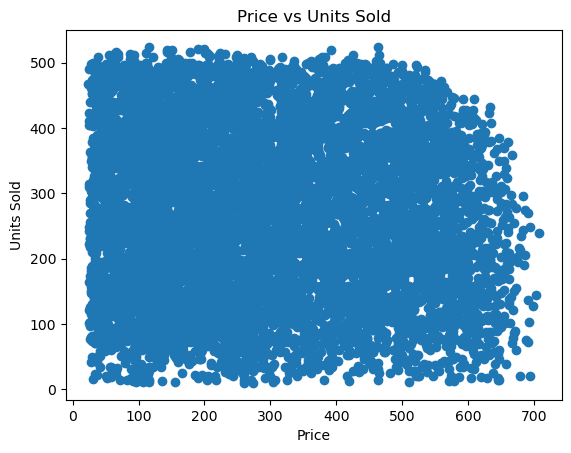

In [149]:
import matplotlib.pyplot as plt

plt.scatter(data["Price"], data["Units Sold"])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()


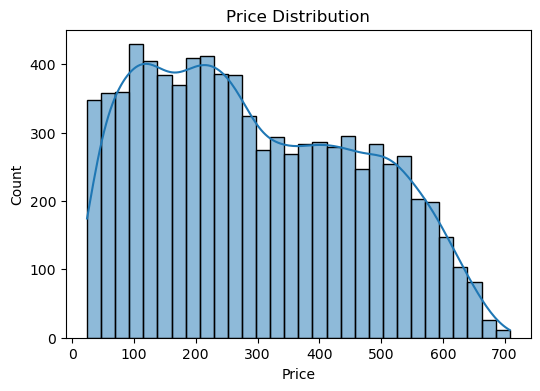

In [70]:
# Price Distribution
import seaborn as sns
plt.figure(figsize=(6,4))
sns.histplot(data['Price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

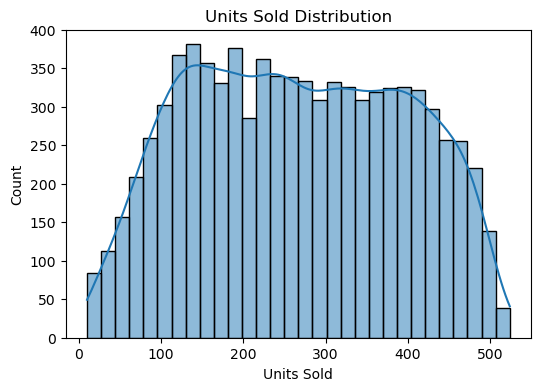

In [74]:
# Units Sold Distribution
plt.figure(figsize=(6,4))
sns.histplot(data['Units Sold'], bins=30, kde=True)
plt.title("Units Sold Distribution")
plt.show()

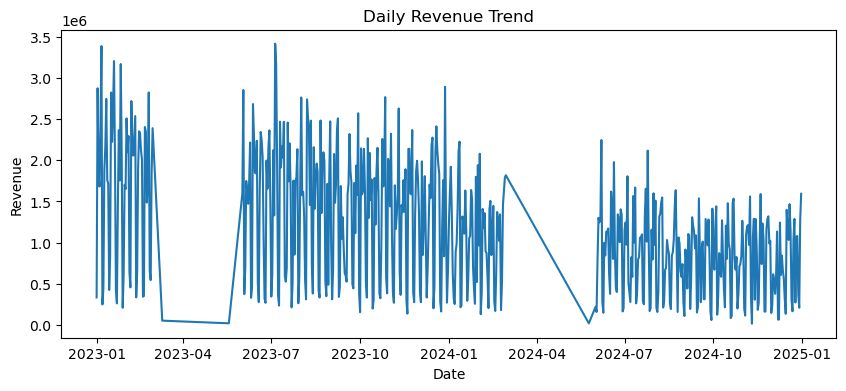

In [78]:
data['Date'] = pd.to_datetime(data['Date'])
daily_revenue = data.groupby(data['Date'].dt.date)['Revenue'].sum()

daily_revenue.plot(figsize=(10,4))
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

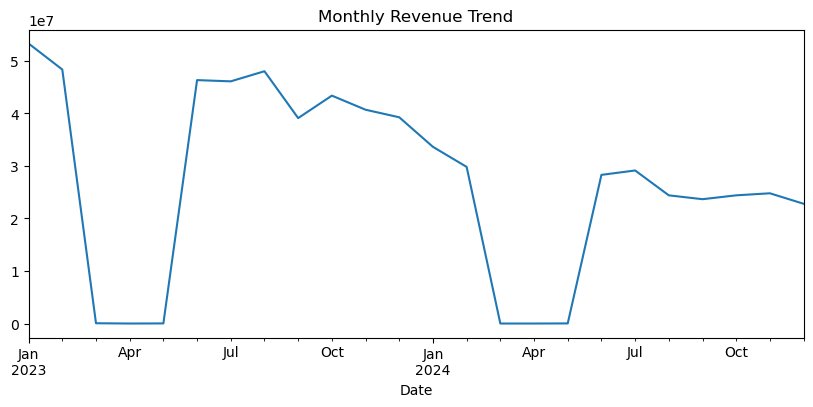

In [80]:
data.set_index("Date").resample("M")["Revenue"].sum().plot(figsize=(10,4))
plt.title("Monthly Revenue Trend")
plt.show()


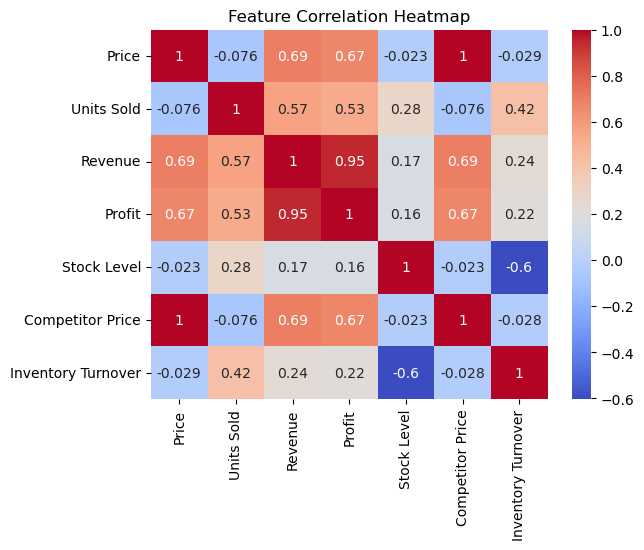

In [82]:
cols = ["Price", "Units Sold", "Revenue", "Profit",
        "Stock Level", "Competitor Price", "Inventory Turnover"]

sns.heatmap(data[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


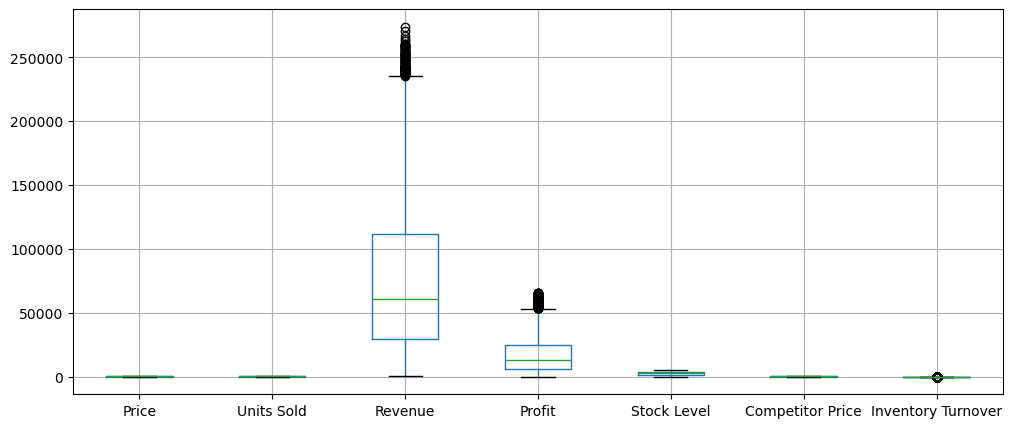

In [84]:
data[cols].boxplot(figsize=(12,5))
plt.show()


### (Milestone 4)PriceOptima – Baseline Rule-Based Pricing Engine

In [61]:
#Weekend demand is higher → price increase
#Festival/peak season → price increase
#Low demand period → discount
#Low stock → price increase
#High stock → discount

In [63]:
import pandas as pd
pd.options.display.float_format = '{:,.2f}'.format

In [65]:
data["rule_price"] = data["Price"]


In [67]:
# Weekend demand surge
data.loc[data["Weekend"] == 1, "rule_price"] *= 1.10

# Festival / peak season pricing
data.loc[data["Holiday"] == 1, "rule_price"] *= 1.15

# Month-end increase
data.loc[data["Date"].dt.day >= 25, "rule_price"] *= 1.05


In [69]:
low_stock_threshold = data["Stock Level"].quantile(0.25)
high_stock_threshold = data["Stock Level"].quantile(0.75)

# Low stock → increase price
data.loc[data["Stock Level"] < low_stock_threshold, "rule_price"] *= 1.15

# High stock → small discount only
data.loc[data["Stock Level"] > high_stock_threshold, "rule_price"] *= 0.97


In [71]:
data["Static_Revenue"] = data["Price"] * data["Units Sold"]
data["Rule_Based_Revenue"] = data["rule_price"] * data["Units Sold"]

revenue_comparison = data[["Static_Revenue", "Rule_Based_Revenue"]].sum()

revenue_comparison_usd = revenue_comparison.apply(lambda x: f"${x:,.2f}")
revenue_comparison_usd

print(revenue_comparison)


Static_Revenue       645,130,820.69
Rule_Based_Revenue   680,073,050.61
dtype: float64


In [73]:
revenue_lift = (
    (revenue_comparison["Rule_Based_Revenue"] -
     revenue_comparison["Static_Revenue"])
    / revenue_comparison["Static_Revenue"]
) * 100

print(f"Revenue Lift: {revenue_lift:.2f}%")


Revenue Lift: 5.42%


In [75]:
data[["Price", "rule_price", "Units Sold"]].head()


,Price,rule_price,Units Sold
15000,138.49,167.23,358
0,131.74,131.74,353
2,349.25,401.64,101
3,232.91,294.63,304
15005,184.57,212.26,207


### Milestone 5 – Advanced Model Development

In [78]:
# Drop rows with missing values
data = data.dropna().reset_index(drop=True)

In [80]:
#Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

cat_cols = ["Product ID", "Product Name", "Category", "Pricing_Type"]

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [82]:
#Define Features (X) and Target (y)
features = [
    "Price", "Competitor Price", "Stock Level",
    "Weekend", "Holiday",
    "Lag_Sales_1", "Lag_Sales_7",
    "Rolling_7", "Rolling_30",
    "Inventory_Ratio", "Profit Margin %"
]

X = data[features]
y = data["Units Sold"]

In [84]:
#Time-Based Train-Test Split
split_date = data["Date"].quantile(0.8)

X_train = X[data["Date"] <= split_date]
X_test  = X[data["Date"] > split_date]

y_train = y[data["Date"] <= split_date]
y_test  = y[data["Date"] > split_date]

In [86]:
#XGBoost Regressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)

XGBoost MAE: 4.283134937286377


In [88]:
#LightGBM Regressor
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)
lgb_mae = mean_absolute_error(y_test, lgb_pred)

print("LightGBM MAE:", lgb_mae)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1526
[LightGBM] [Info] Number of data points in the train set: 6697, number of used features: 8
[LightGBM] [Info] Start training from score 268.513514
LightGBM MAE: 3.5450036047019498


In [89]:
#ML-Based Dynamic Pricing
data_test = data[data["Date"] > split_date].copy()

data_test["Predicted_Demand"] = lgb_pred

data_test["ml_price"] = data_test["Price"]

# High demand → increase price
data_test.loc[
    data_test["Predicted_Demand"] > data_test["Units Sold"].mean(),
    "ml_price"
] *= 1.05

# Low demand → decrease price
data_test.loc[
    data_test["Predicted_Demand"] <= data_test["Units Sold"].mean(),
    "ml_price"
] *= 0.95


In [92]:
#Revenue Calculation
# Static pricing revenue
data_test["Static_Revenue"] = data_test["Price"] * data_test["Units Sold"]

# Rule-based revenue (from Milestone 4)
data_test["Rule_Based_Revenue"] = data_test["rule_price"] * data_test["Units Sold"]

# ML-based revenue
data_test["ML_Revenue"] = data_test["ml_price"] * data_test["Units Sold"]


In [94]:
#Revenue Comparison Table
revenue_summary = data_test[
    ["Static_Revenue", "Rule_Based_Revenue", "ML_Revenue"]
].sum()

In [96]:
revenue_summary

Static_Revenue       123,892,098.51
Rule_Based_Revenue   130,595,626.65
ML_Revenue           125,992,419.31
dtype: float64

In [98]:
#Revenue Lift Calculation
ml_revenue_lift = (
    (revenue_summary["ML_Revenue"] - revenue_summary["Static_Revenue"])
    / revenue_summary["Static_Revenue"]
) * 100

print(f"ML Revenue Lift: {ml_revenue_lift:.2f}%")


ML Revenue Lift: 1.70%


In [104]:
import joblib

joblib.dump(lgb, "priceoptima_lgb_model.joblib")

['priceoptima_lgb_model.joblib']